# Day-Ahead Power Price Forecasting — Walkthrough

End-to-end walkthrough of the GB day-ahead price model. Pulls real data from Elexon BMRS (power) and Yahoo Finance (fuel & carbon), engineers fundamentals + calendar + lagged-price features, and trains three models in increasing complexity.A seasonal naive baseline, a ridge regression, and LightGBM.

**The model inputs.** Five things the GB market knows before the day-ahead auction clears at 11:00 CET:

1. **Load forecast** — how much electricity GB will need
2. **Wind forecast** — how much wind generation will show up
3. **Solar forecast** — how much solar generation will show up (proxied via AGWS-shifted-24h since Elexon retired the dedicated solar forecast)
4. **TTF gas** — yesterday's close as a proxy for tomorrow's CCGT marginal cost
5. **KEUA carbon** — yesterday's close as a proxy for the CO2 component of marginal cost

Together these tell the model where on the merit-order curve the price setting plant will sit and roughly what it will charge.

**Plan**
1. Load the merged dataset.
2. Inspect the fuel series and check they move with power prices.
3. Confirm the merit-order story holds in the data.
4. Build the feature matrix.
5. Walk-forward cross-validation across the three models.
6. does the fuel layer earn its place?
7. Final-fold diagnostics: actual vs predicted, residuals, feature importance.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'config.yaml').exists():
            return p
    raise RuntimeError('Could not find project root')

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
print('ROOT =', ROOT)

from src.features import build_feature_matrix, feature_columns
from src.models import SeasonalNaive, LinearModel, LightGBMModel
from src.evaluate import expanding_window_folds, walk_forward_evaluate, summarise, all_metrics

sns.set_theme(style='whitegrid', context='talk')
cfg = yaml.safe_load((ROOT / 'config.yaml').read_text())

ROOT = c:\Users\dappy\Downloads\Public-portfolio\Energy\power_price_forecasting - In_dev\power_price_forecasting_v2


## 1. Data

In [2]:
raw = pd.read_parquet(ROOT / cfg['data']['raw_dir'] / f"{cfg['market']['country_code']}_hourly.parquet")
print(f'{len(raw):,} hourly rows, {raw.index.min()} -> {raw.index.max()}')
raw[['day_ahead_price', 'load_forecast', 'wind_forecast', 'solar_forecast', 'ttf_gas', 'eua_carbon']].head()

15,822 hourly rows, 2023-08-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00


,day_ahead_price,load_forecast,wind_forecast,solar_forecast,ttf_gas,eua_carbon
timestamp_utc,,,,,,
2023-08-01 00:00:00+00:00,60.250,19226.0,6969.0,0.0,28.365999,32.581699
2023-08-01 01:00:00+00:00,52.065,18879.5,7071.0,0.0,28.365999,32.581699
2023-08-01 02:00:00+00:00,48.995,18938.5,7101.0,0.0,28.365999,32.581699
2023-08-01 03:00:00+00:00,52.875,19147.5,7046.0,0.0,28.365999,32.581699
2023-08-01 04:00:00+00:00,44.450,20145.5,6927.0,3.5,28.365999,32.581699


## 2. The fuel series


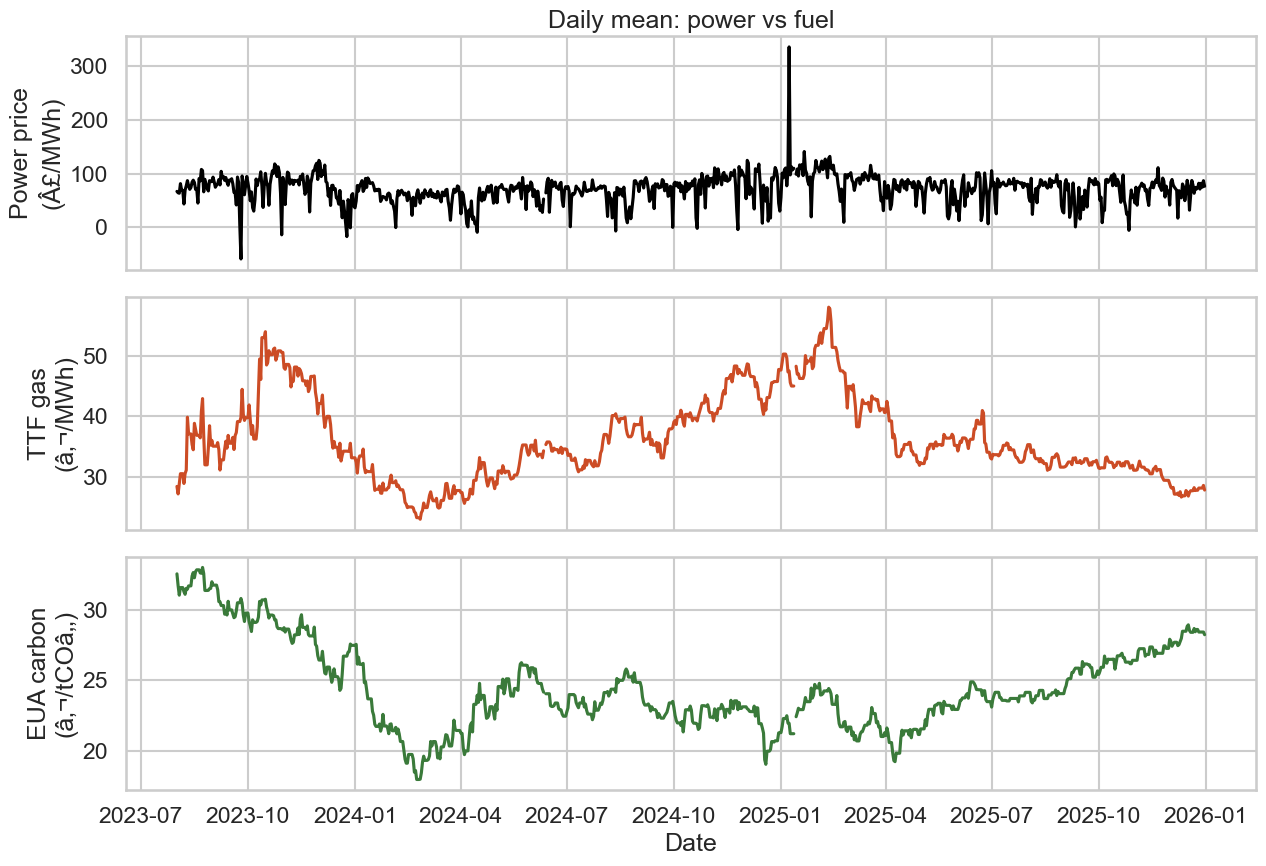

In [3]:
daily = raw[['day_ahead_price', 'ttf_gas', 'eua_carbon']].resample('1D').mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(daily.index, daily['day_ahead_price'], color='black')
axes[0].set_ylabel('Power price\n(Â£/MWh)')
axes[1].plot(daily.index, daily['ttf_gas'], color='#cc4c25')
axes[1].set_ylabel('TTF gas\n(â‚¬/MWh)')
axes[2].plot(daily.index, daily['eua_carbon'], color='#3a7a3a')
axes[2].set_ylabel('EUA carbon\n(â‚¬/tCOâ‚‚)')
axes[2].set_xlabel('Date')
axes[0].set_title('Daily mean: power vs fuel')
plt.tight_layout()
plt.show()

In [4]:
# Correlation check (daily means)
daily.corr().round(3)

,day_ahead_price,ttf_gas,eua_carbon
day_ahead_price,1.000,0.375,0.069
ttf_gas,0.375,1.000,0.107
eua_carbon,0.069,0.107,1.000


## 3. Merit-order check still holds

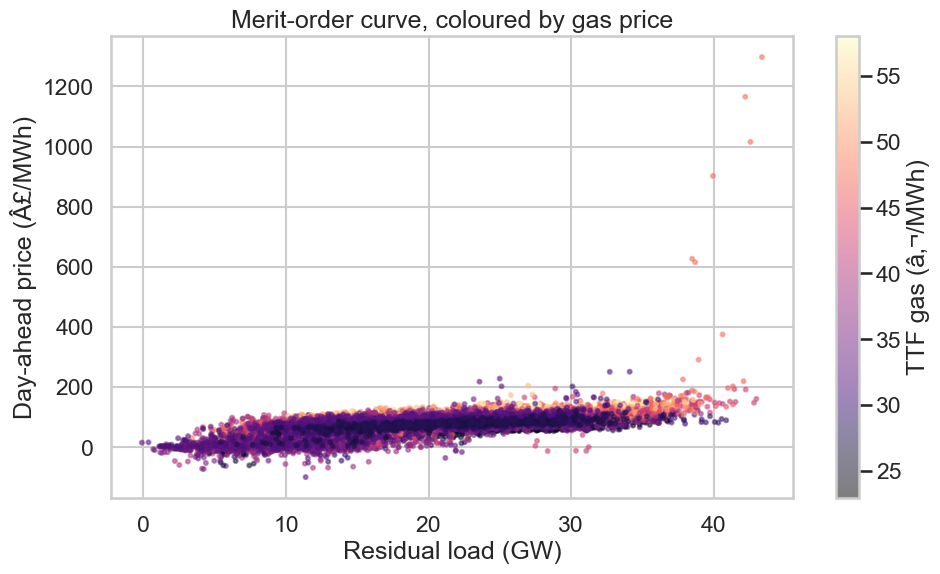

In [5]:
raw['residual_load'] = raw['load_forecast'] - raw['wind_forecast'] - raw['solar_forecast']

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(raw['residual_load']/1000, raw['day_ahead_price'],
                c=raw['ttf_gas'], cmap='magma', alpha=0.5, s=8)
plt.colorbar(sc, label='TTF gas (â‚¬/MWh)')
ax.set_xlabel('Residual load (GW)')
ax.set_ylabel('Day-ahead price (Â£/MWh)')
ax.set_title('Merit-order curve, coloured by gas price')
plt.show()

## 4. Feature matrix

In [6]:
feats = build_feature_matrix(
    raw[['day_ahead_price', 'load_forecast', 'wind_forecast', 'solar_forecast', 'ttf_gas', 'eua_carbon']],
    tz=cfg['market']['timezone'],
    price_lags=cfg['features']['price_lags'],
    rolling_windows=cfg['features']['rolling_windows'],
    use_holidays=cfg['features']['use_holidays'],
    holiday_country=cfg['features']['holiday_country'],
)
cols = feature_columns(feats)
X, y = feats[cols], feats['day_ahead_price']
print(f'{len(X):,} rows x {len(cols)} features')
cols

15,631 rows x 23 features


['load_forecast',
 'wind_forecast',
 'solar_forecast',
 'residual_load',
 'renewable_share',
 'ttf_gas',
 'eua_carbon',
 'hour',
 'dayofweek',
 'month',
 'is_weekend',
 'is_holiday',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'day_ahead_price_lag_24h',
 'day_ahead_price_lag_48h',
 'day_ahead_price_lag_168h',
 'day_ahead_price_rollmean_24h',
 'day_ahead_price_rollmean_168h',
 'day_ahead_price_rollstd_24h',
 'day_ahead_price_rollstd_168h']

## 5. Walk-forward CV

In [7]:
folds = expanding_window_folds(
    feats.index,
    n_folds=cfg['model']['cv_folds'],
    test_horizon_days=cfg['model']['test_horizon_days'] // cfg['model']['cv_folds'],
)
factories = {
    'seasonal_naive_168h': lambda: SeasonalNaive(),
    'ridge':               lambda: LinearModel(alpha=1.0),
    'lightgbm':            lambda: LightGBMModel(params=cfg['model']['lightgbm']),
}
results = {name: walk_forward_evaluate(f, X, y, folds) for name, f in factories.items()}
summary = pd.DataFrame({n: summarise(r) for n, r in results.items()}).T
summary.round(2)

c:\Users\dappy\anaconda3\envs\pylearn\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dappy\anaconda3\envs\pylearn\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\dappy\anaconda3\envs\pylearn\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dappy\anaconda3\envs\pylearn\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\dappy\anaconda3\envs\pylearn\Lib\subprocess.py", line

,MAE,RMSE,MAPE_%
seasonal_naive_168h,19.58,27.48,116.64
ridge,14.27,18.40,47.88
lightgbm,13.06,18.15,42.54


## 6. does fuel actually help?


In [8]:
fuel_cols = ['ttf_gas', 'eua_carbon']
no_fuel_cols = [c for c in cols if c not in fuel_cols]

with_fuel = walk_forward_evaluate(
    lambda: LightGBMModel(params=cfg['model']['lightgbm']),
    feats[cols], y, folds,
)['MAE']
without_fuel = walk_forward_evaluate(
    lambda: LightGBMModel(params=cfg['model']['lightgbm']),
    feats[no_fuel_cols], y, folds,
)['MAE']

ablation = pd.DataFrame({
    'without_fuel_MAE': without_fuel,
    'with_fuel_MAE':    with_fuel,
    'improvement_pct':  100 * (without_fuel - with_fuel) / without_fuel,
}).round(2)
ablation

,without_fuel_MAE,with_fuel_MAE,improvement_pct
fold,,,
1,12.12,11.51,5.05
2,20.19,18.73,7.25
3,11.04,11.78,-6.73
4,13.10,12.13,7.43
5,10.69,11.17,-4.55


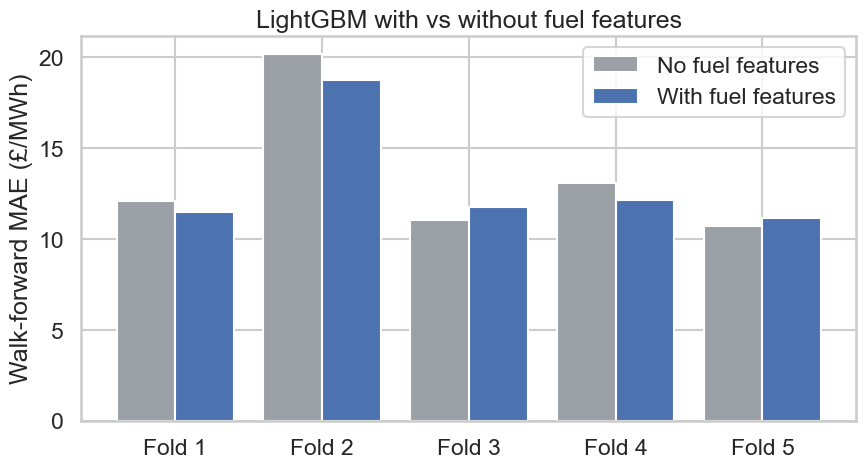

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ablation))
w = 0.4
ax.bar(x - w/2, ablation['without_fuel_MAE'], w, label='No fuel features', color='#9aa0a6')
ax.bar(x + w/2, ablation['with_fuel_MAE'],    w, label='With fuel features',  color='#4c72b0')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(len(ablation))])
ax.set_ylabel('Walk-forward MAE (£/MWh)')
ax.set_title('LightGBM with vs without fuel features')
ax.legend()
plt.show()

## 7. Final-fold diagnostics

In [10]:
final = folds[-1]
X_tr, y_tr = feats[cols].loc[final.train_idx], y.loc[final.train_idx]
X_te, y_te = feats[cols].loc[final.test_idx],  y.loc[final.test_idx]

lgbm = LightGBMModel(params=cfg['model']['lightgbm']).fit(X_tr, y_tr)
y_pred = lgbm.predict(X_te)
all_metrics(y_te, y_pred)

{'MAE': 11.171654595894449,
 'RMSE': 16.106576491163096,
 'MAPE_%': 47.86421944825373}

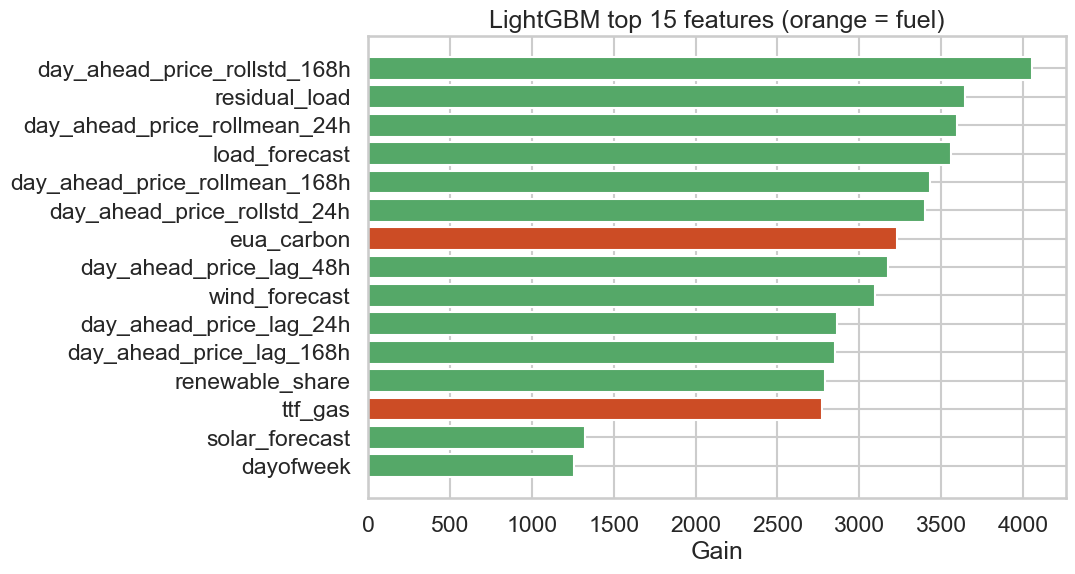

In [11]:
imp = lgbm.feature_importance(cols).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#cc4c25' if c in fuel_cols else '#55a868' for c in imp.index]
ax.barh(imp.index, imp.values, color=colors)
ax.set_xlabel('Gain')
ax.set_title('LightGBM top 15 features (orange = fuel)')
plt.show()

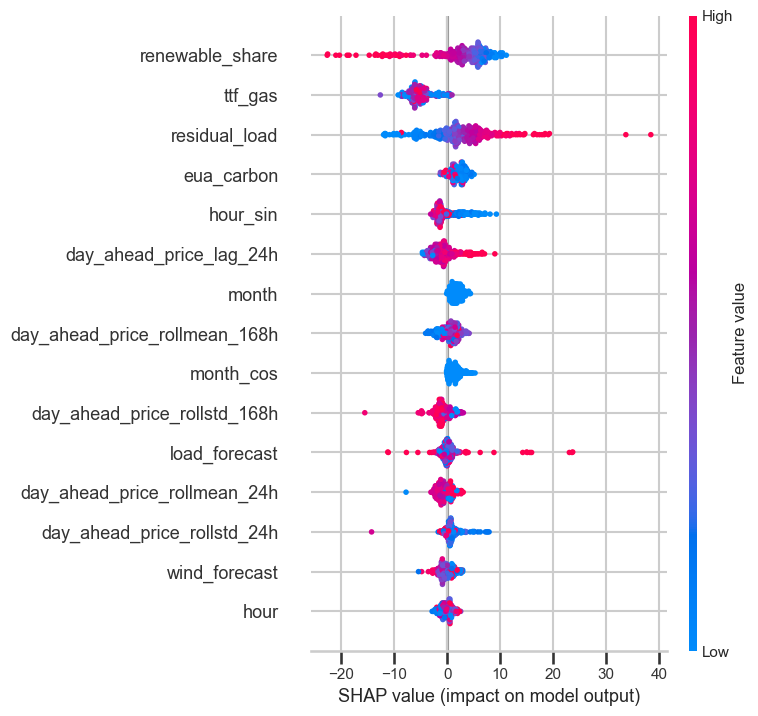

In [12]:
import shap

# Sample down for speed â€” SHAP is O(n_test) and can be slow
sample = X_te.sample(min(len(X_te), 2000), random_state=42)

explainer = shap.TreeExplainer(lgbm._model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, max_display=15)

## 8. What this model still doesn't capture

Known price drivers not yet included in the model, candidates for a future iteration:

-Plant outages — needs Elexon REMIT messages. the merit order can shift when a 2 GW nuclear unit trips.
- Interconnector flows / continental prices* — GB has approx 9 GW of import capacity needs ENTSO-E for DE/FR/NL prices.
- Wind/solar forecast errors — pair forecast with actual, lag the error. captures the variance in renewables performance vs published forecasts.
- Battery / DSR — Elexon publishes some battery dispatch but constructing a useful feature is complcated.

Each is a known gap, deliberately scoped out for the first useful iteration.